# 09 - Model Evaluation

## Analytical Objectives

- Load the evaluation results from all forecasting models.
- Compare Naïve Baseline, Prophet, XGBoost, and LightGBM.
- Compare models using MAE, RMSE, and MAPE.
- Analyze actual versus predicted sales.
- Examine forecast error distributions.
- Evaluate model performance across stores.
- Evaluate model performance across departments.
- Analyze model performance during holiday periods.
- Identify the best-performing forecasting model.
- Select the final model for Walmart sales forecasting.
- Document business implications of the selected model.

## Expected Outcome

By the end of this notebook, we will have:

- A complete comparison of all forecasting models.
- Identification of the best-performing model.
- Understanding of model strengths and weaknesses.
- Store-level and department-level error analysis.
- A final model selection supported by quantitative evidence.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Load Model Comparison

In [2]:
model_comparison = pd.read_csv(
    "../reports/figures/model_comparison.csv"
)

model_comparison

,Model,MAE,RMSE,MAPE,Unnamed: 0
0,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN
1,LightGBM,1.234192e+03,2.564796e+03,1.738107e+16,NaN
2,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
3,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0


In [3]:
model_comparison.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Model       4 non-null      str    
 1   MAE         4 non-null      float64
 2   RMSE        4 non-null      float64
 3   MAPE        4 non-null      float64
 4   Unnamed: 0  1 non-null      float64
dtypes: float64(4), str(1)
memory usage: 292.0 bytes


#### Sort Models by MAE

In [4]:
model_comparison = (
    model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_comparison

,Model,MAE,RMSE,MAPE,Unnamed: 0
0,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN
1,LightGBM,1.234192e+03,2.564796e+03,1.738107e+16,NaN
2,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
3,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0


#### Rank by RMSE,MAPE

In [5]:
rmse_ranking = (
    model_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

rmse_ranking

,Model,MAE,RMSE,MAPE,Unnamed: 0
0,LightGBM,1.234192e+03,2.564796e+03,1.738107e+16,NaN
1,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN
2,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
3,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0


In [6]:
mape_ranking = (
    model_comparison
    .sort_values("MAPE")
    .reset_index(drop=True)
)

mape_ranking

,Model,MAE,RMSE,MAPE,Unnamed: 0
0,Prophet,1.385515e+06,1.838681e+06,2.945324e+00,0.0
1,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15,NaN
2,LightGBM,1.234192e+03,2.564796e+03,1.738107e+16,NaN
3,XGBoost,1.200495e+03,2.602177e+03,1.813349e+16,NaN


#### MAE,RMSE,MAPE Comparison

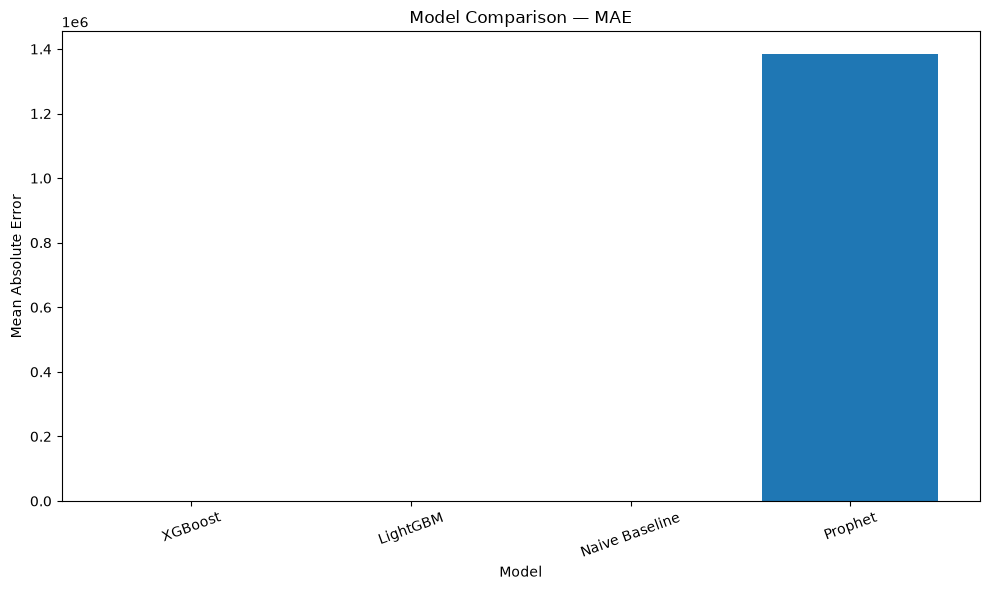

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

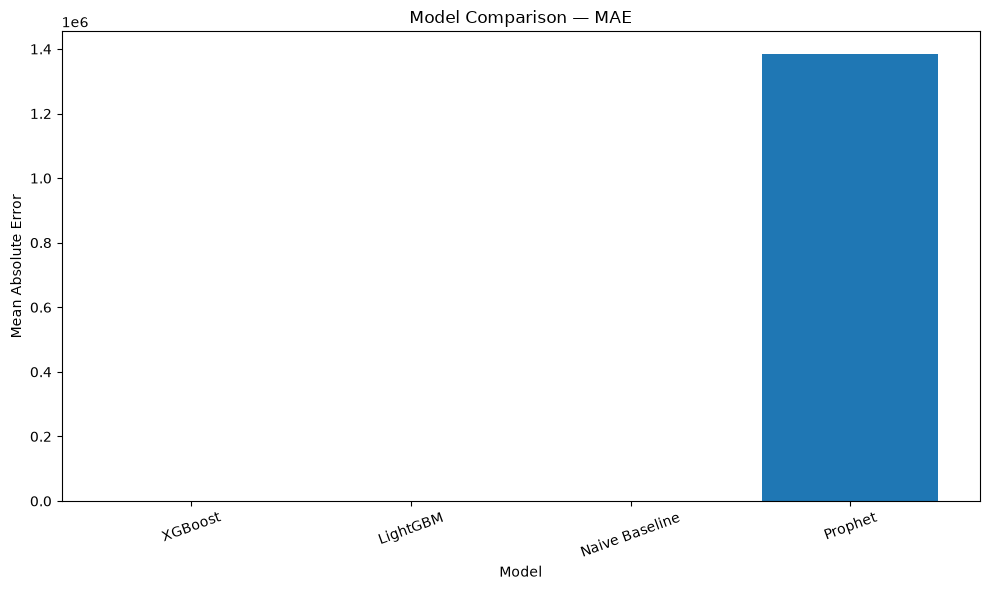

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

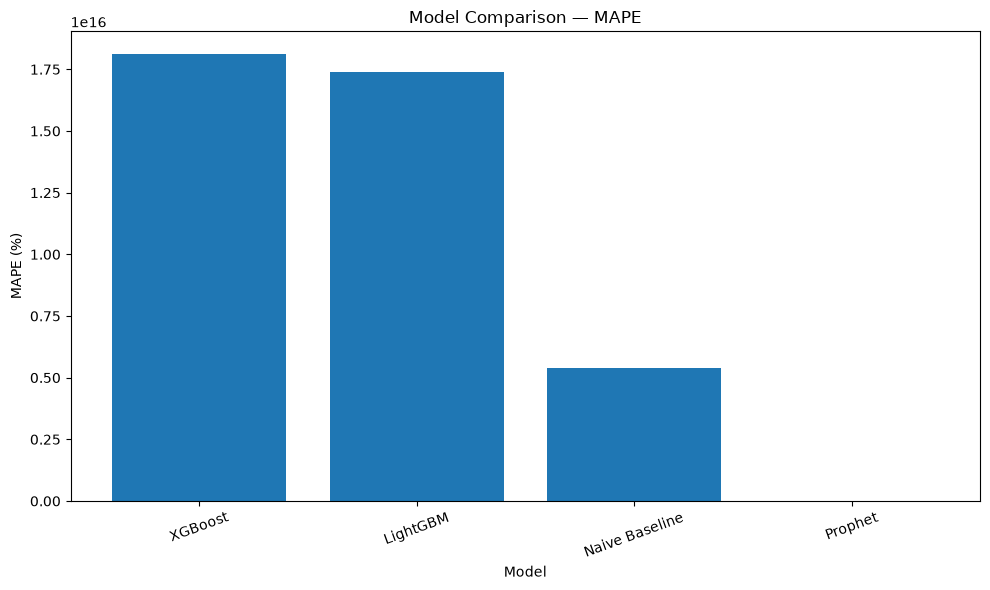

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAPE"]
)

plt.title("Model Comparison — MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### Identify the Best Model

In [10]:
#MAE:

best_model_mae = (
    model_comparison
    .loc[
        model_comparison["MAE"].idxmin(),
        "Model"
    ]
)

best_mae = (
    model_comparison["MAE"].min()
)

print("Best Model by MAE:", best_model_mae)
print(f"Best MAE: {best_mae:,.2f}")

Best Model by MAE: XGBoost
Best MAE: 1,200.49


In [11]:
#RMSE:

best_model_rmse = (
    model_comparison
    .loc[
        model_comparison["RMSE"].idxmin(),
        "Model"
    ]
)

best_rmse = (
    model_comparison["RMSE"].min()
)

print("Best Model by RMSE:", best_model_rmse)
print(f"Best RMSE: {best_rmse:,.2f}")

Best Model by RMSE: LightGBM
Best RMSE: 2,564.80


#### Load Predictions

In [12]:
#XGBoost

xgb_results = pd.read_csv(
    "../data/processed/xgb_predictions.csv"
)

xgb_results["Date"] = pd.to_datetime(
    xgb_results["Date"]
)

In [14]:
#LightGBM

lgbm_results = pd.read_csv(
    "../data/processed/lightgbm_predictions.csv"
)

lgbm_results["Date"] = pd.to_datetime(
    lgbm_results["Date"]
)

#### Inspect Prediction Files

In [15]:
xgb_results.head()

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
0,2012-06-01,1,1,16065.49,17168.440,-1102.949453
1,2012-06-01,1,2,47425.29,49252.700,-1827.409219
2,2012-06-01,1,3,7175.77,8814.381,-1638.610859
3,2012-06-01,1,4,41566.55,42708.004,-1141.453906
4,2012-06-01,1,5,17233.25,19112.322,-1879.072266


In [16]:
lgbm_results.head()

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
0,2012-06-01,1,1,16065.49,18481.847220,-2416.357220
1,2012-06-01,1,2,47425.29,48238.678069,-813.388069
2,2012-06-01,1,3,7175.77,9029.036889,-1853.266889
3,2012-06-01,1,4,41566.55,40204.481931,1362.068069
4,2012-06-01,1,5,17233.25,18666.336535,-1433.086535


#### Compare XGBoost vs LightGBM

In [17]:
#Create a combined table:

boosting_comparison = xgb_results[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales"
    ]
].copy()

In [18]:
#Rename:

boosting_comparison = boosting_comparison.rename(
    columns={
        "Predicted_Sales": "XGBoost_Predicted"
    }
)

In [19]:
#Merge LightGBM:

boosting_comparison = boosting_comparison.merge(
    lgbm_results[
        [
            "Date",
            "Store",
            "Dept",
            "Predicted_Sales"
        ]
    ],
    on=["Date", "Store", "Dept"],
    how="inner"
)

In [20]:
#Rename:

boosting_comparison = boosting_comparison.rename(
    columns={
        "Predicted_Sales": "LightGBM_Predicted"
    }
)

In [21]:
#Check:

boosting_comparison.head()

,Date,Store,Dept,Weekly_Sales,XGBoost_Predicted,LightGBM_Predicted
0,2012-06-01,1,1,16065.49,17168.440,18481.847220
1,2012-06-01,1,2,47425.29,49252.700,48238.678069
2,2012-06-01,1,3,7175.77,8814.381,9029.036889
3,2012-06-01,1,4,41566.55,42708.004,40204.481931
4,2012-06-01,1,5,17233.25,19112.322,18666.336535


#### Calculate Model Errors

In [22]:
boosting_comparison["XGBoost_Error"] = (
    boosting_comparison["Weekly_Sales"]
    - boosting_comparison["XGBoost_Predicted"]
)

In [23]:
boosting_comparison["LightGBM_Error"] = (
    boosting_comparison["Weekly_Sales"]
    - boosting_comparison["LightGBM_Predicted"]
)

In [24]:
#Absolute errors:

boosting_comparison["XGBoost_Absolute_Error"] = (
    boosting_comparison["XGBoost_Error"]
    .abs()
)

In [25]:
boosting_comparison["LightGBM_Absolute_Error"] = (
    boosting_comparison["LightGBM_Error"]
    .abs()
)

#### Compare Boosting Models

In [26]:
boosting_metrics = pd.DataFrame({
    "Model": [
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        boosting_comparison["XGBoost_Absolute_Error"].mean(),
        boosting_comparison["LightGBM_Absolute_Error"].mean()
    ],
    "RMSE": [
        np.sqrt(
            np.mean(
                boosting_comparison["XGBoost_Error"] ** 2
            )
        ),
        np.sqrt(
            np.mean(
                boosting_comparison["LightGBM_Error"] ** 2
            )
        )
    ]
})

boosting_metrics

,Model,MAE,RMSE
0,XGBoost,1200.494661,2602.177307
1,LightGBM,1234.191681,2564.795642


#### Actual vs Predicted — XGBoost

In [27]:
weekly_xgb = (
    xgb_results
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

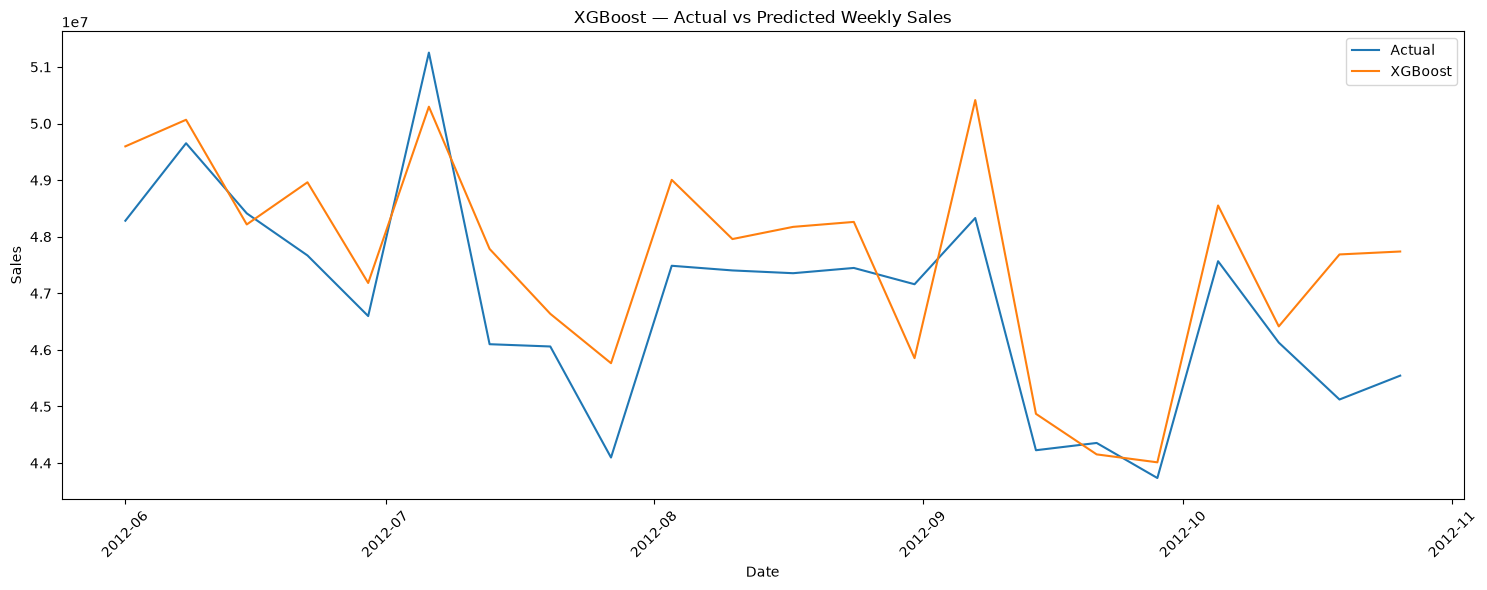

In [28]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_xgb["Date"],
    weekly_xgb["Actual_Sales"],
    label="Actual"
)

plt.plot(
    weekly_xgb["Date"],
    weekly_xgb["Predicted_Sales"],
    label="XGBoost"
)

plt.title(
    "XGBoost — Actual vs Predicted Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Actual vs Predicted — LightGBM

In [29]:
weekly_lgbm = (
    lgbm_results
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

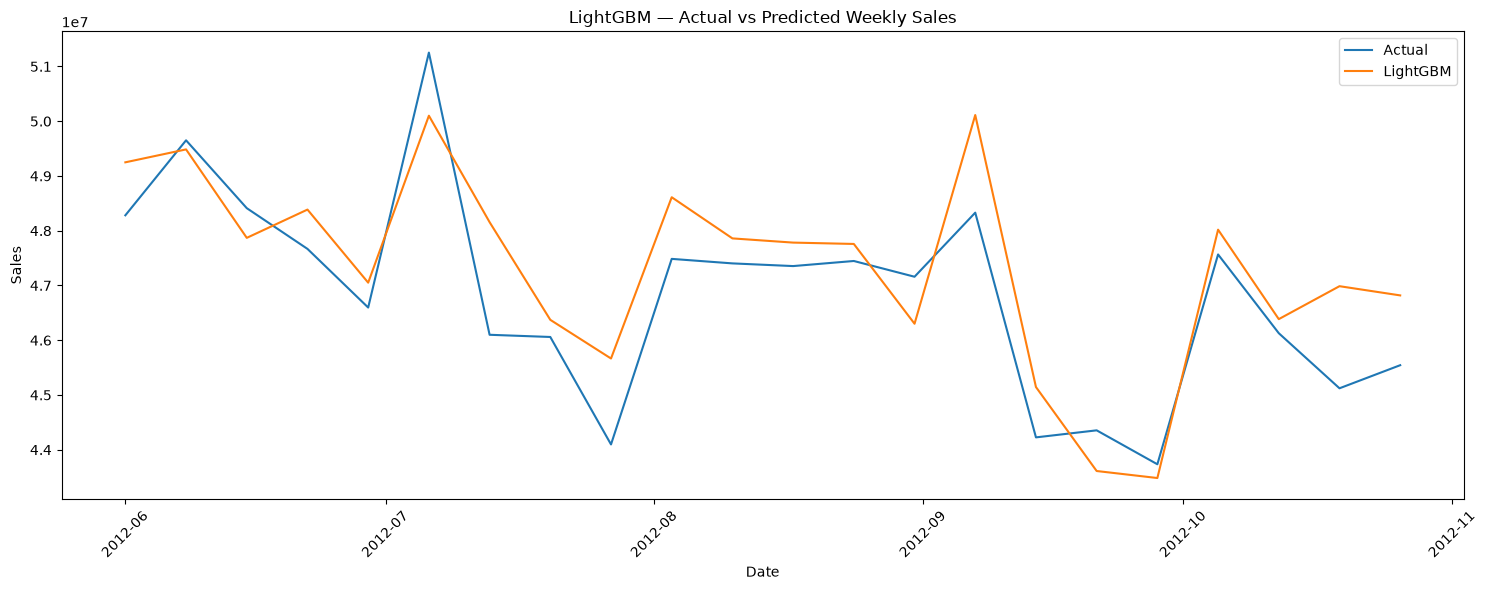

In [30]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_lgbm["Date"],
    weekly_lgbm["Actual_Sales"],
    label="Actual"
)

plt.plot(
    weekly_lgbm["Date"],
    weekly_lgbm["Predicted_Sales"],
    label="LightGBM"
)

plt.title(
    "LightGBM — Actual vs Predicted Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Compare XGBoost and LightGBM Forecasts

In [31]:
weekly_boosting = (
    boosting_comparison
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        XGBoost=("XGBoost_Predicted", "sum"),
        LightGBM=("LightGBM_Predicted", "sum")
    )
    .reset_index()
)

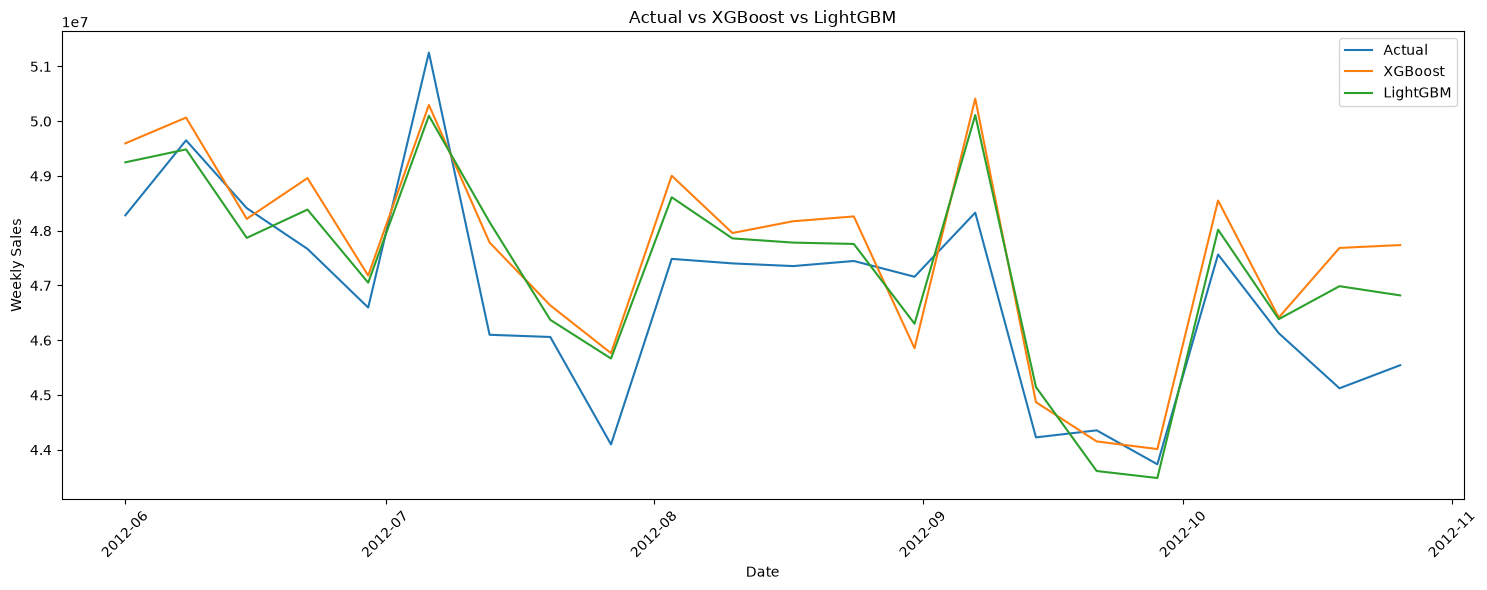

In [32]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_boosting["Date"],
    weekly_boosting["Actual_Sales"],
    label="Actual"
)

plt.plot(
    weekly_boosting["Date"],
    weekly_boosting["XGBoost"],
    label="XGBoost"
)

plt.plot(
    weekly_boosting["Date"],
    weekly_boosting["LightGBM"],
    label="LightGBM"
)

plt.title(
    "Actual vs XGBoost vs LightGBM"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Error Distribution

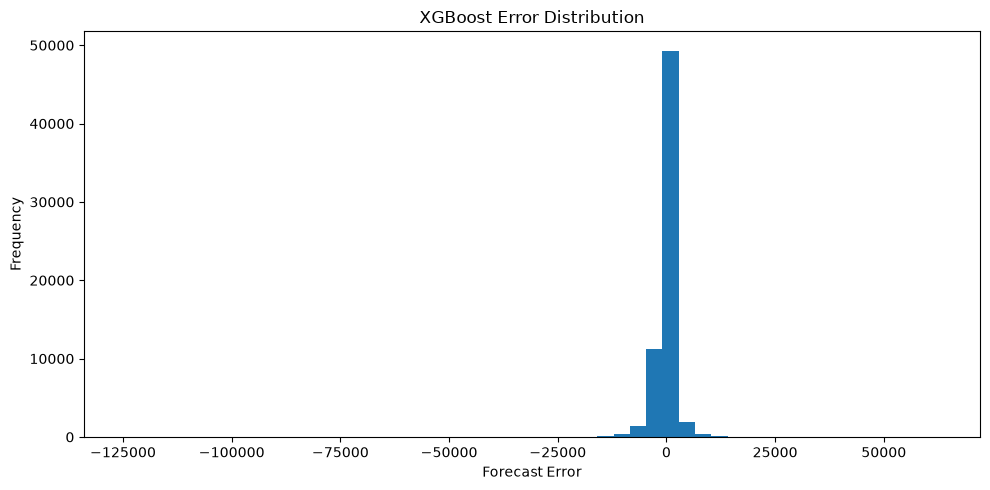

In [33]:
#XGBoost

plt.figure(figsize=(10, 5))

plt.hist(
    boosting_comparison["XGBoost_Error"],
    bins=50
)

plt.title(
    "XGBoost Error Distribution"
)

plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

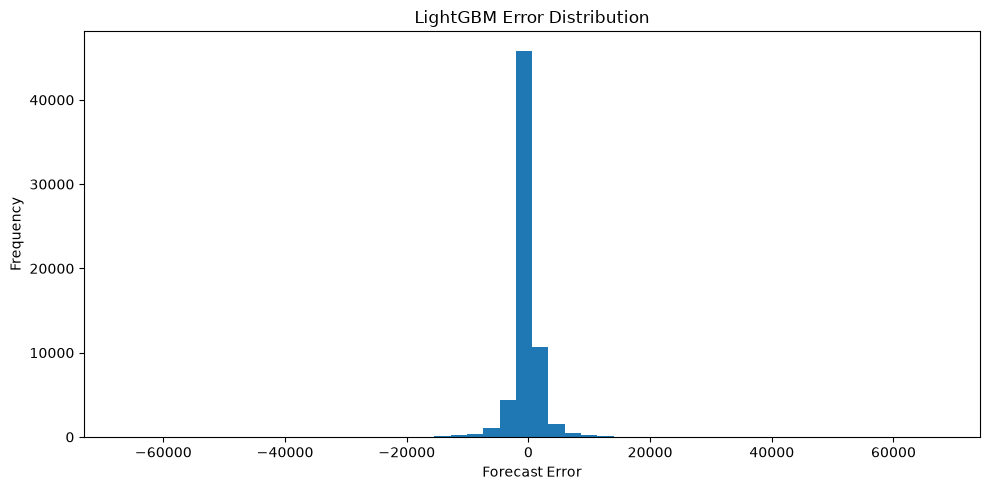

In [34]:
#LightGBM

plt.figure(figsize=(10, 5))

plt.hist(
    boosting_comparison["LightGBM_Error"],
    bins=50
)

plt.title(
    "LightGBM Error Distribution"
)

plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Store-Level Performance

In [35]:
#XGBoost store-level MAE:

xgb_store_performance = (
    xgb_results
    .assign(
        Absolute_Error=lambda df:
        (
            df["Weekly_Sales"]
            - df["Predicted_Sales"]
        ).abs()
    )
    .groupby("Store")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

In [36]:
#Sort:

xgb_store_performance.sort_values(
    "MAE",
    ascending=False
).head(10)

,Store,MAE,Actual_Sales,Predicted_Sales
13,14,3196.920564,37116269.71,4.073685e+07
3,4,1975.636611,47370986.89,4.887494e+07
19,20,1952.646631,45988694.58,4.641236e+07
12,13,1846.324628,45017592.40,4.571192e+07
22,23,1819.660089,31791326.64,3.276043e+07
26,27,1770.250430,38002367.14,3.863245e+07
9,10,1716.579465,38871644.97,3.956633e+07
1,2,1634.091462,41536882.28,4.194079e+07
18,19,1515.665334,30736722.32,3.121297e+07
23,24,1499.917864,30474057.39,3.067835e+07


#### LightGBM Store-Level Performance

In [37]:
lgbm_store_performance = (
    lgbm_results
    .assign(
        Absolute_Error=lambda df:
        (
            df["Weekly_Sales"]
            - df["Predicted_Sales"]
        ).abs()
    )
    .groupby("Store")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

In [38]:
lgbm_store_performance.sort_values(
    "MAE",
    ascending=False
).head(10)

,Store,MAE,Actual_Sales,Predicted_Sales
13,14,2952.177317,37116269.71,4.022673e+07
19,20,2037.349234,45988694.58,4.621069e+07
12,13,1884.599113,45017592.40,4.550076e+07
3,4,1843.324946,47370986.89,4.796185e+07
26,27,1822.527198,38002367.14,3.846443e+07
22,23,1751.755746,31791326.64,3.207297e+07
9,10,1732.792961,38871644.97,3.952900e+07
1,2,1707.940527,41536882.28,4.182759e+07
18,19,1583.088325,30736722.32,3.120020e+07
23,24,1543.832839,30474057.39,3.056478e+07


#### Department-Level Performance

In [39]:
xgb_dept_performance = (
    xgb_results
    .assign(
        Absolute_Error=lambda df:
        (
            df["Weekly_Sales"]
            - df["Predicted_Sales"]
        ).abs()
    )
    .groupby("Dept")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

In [40]:
#Top departments by error:

xgb_dept_performance.sort_values(
    "MAE",
    ascending=False
).head(10)

,Dept,MAE,Actual_Sales,Predicted_Sales
36,38,5439.384871,59169893.53,6.111675e+07
59,72,5406.595910,39260467.65,4.054228e+07
56,65,3742.663727,1060368.56,9.991842e+05
72,92,3542.232512,77140148.65,7.784937e+07
75,95,3256.326194,72660033.99,7.379401e+07
10,11,2893.926564,15239720.64,1.544851e+07
6,7,2595.276800,20773364.16,2.150265e+07
4,5,2415.188027,16060522.63,1.646450e+07
8,9,2352.994569,23369918.17,2.377039e+07
2,3,2305.119439,15417358.16,1.566647e+07


#### Holiday Performance

In [41]:
clean_data = pd.read_csv(
    "../data/processed/train_clean.csv"
)

clean_data["Date"] = pd.to_datetime(
    clean_data["Date"]
)

In [42]:
#Select the relevant columns:

holiday_data = clean_data[
    [
        "Date",
        "Store",
        "Dept",
        "IsHoliday"
    ]
]

In [43]:
#Merge with XGBoost predictions:

xgb_holiday = xgb_results.merge(
    holiday_data,
    on=["Date", "Store", "Dept"],
    how="left"
)

In [45]:
#Calculate error:

xgb_holiday["Absolute_Error"] = (
    xgb_holiday["Weekly_Sales"]
    - xgb_holiday["Predicted_Sales"]
).abs()

In [46]:
#Compare:

xgb_holiday_performance = (
    xgb_holiday
    .groupby("IsHoliday")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Actual_Sales=("Weekly_Sales", "mean"),
        Predicted_Sales=("Predicted_Sales", "mean")
    )
    .reset_index()
)

xgb_holiday_performance

,IsHoliday,MAE,Actual_Sales,Predicted_Sales
0,False,1186.172842,15803.714287,16053.733487
1,True,1500.427161,16294.692957,16997.340267


#### Determine the Best Model

In [49]:
#MAE

best_model = (
    model_comparison.
    sort_values("MAE")
    .iloc[0]
)

In [50]:
#Display:

print(
    "Selected Model:",
    best_model["Model"]
)

print(
    f"MAE: {best_model['MAE']:,.2f}"
)

print(
    f"RMSE: {best_model['RMSE']:,.2f}"
)

print(
    f"MAPE: {best_model['MAPE']:.2f}%"
)

Selected Model: XGBoost
MAE: 1,200.49
RMSE: 2,602.18
MAPE: 18133494391951776.00%


#### Check Whether MAE and RMSE Agree

In [51]:
mae_winner = (
    model_comparison
    .loc[
        model_comparison["MAE"].idxmin(),
        "Model"
    ]
)

rmse_winner = (
    model_comparison
    .loc[
        model_comparison["RMSE"].idxmin(),
        "Model"
    ]
)

print("MAE Winner:", mae_winner)
print("RMSE Winner:", rmse_winner)

MAE Winner: XGBoost
RMSE Winner: LightGBM


#### Calculate Improvement Over Baseline

In [52]:
baseline_mae = model_comparison.loc[
    model_comparison["Model"]
    .str.lower()
    .str.contains("naive|baseline"),
    "MAE"
].iloc[0]

In [53]:
#Calculate improvement:

best_model_mae = best_model["MAE"]

improvement = (
    (baseline_mae - best_model_mae)
    / baseline_mae
) * 100

print(
    f"MAE Improvement Over Baseline: "
    f"{improvement:.2f}%"
)

MAE Improvement Over Baseline: 22.09%


#### Create Final Evaluation Summary

In [54]:
evaluation_summary = pd.DataFrame({
    "Selected_Model": [
        best_model["Model"]
    ],
    "MAE": [
        best_model["MAE"]
    ],
    "RMSE": [
        best_model["RMSE"]
    ],
    "MAPE": [
        best_model["MAPE"]
    ],
    "Baseline_MAE": [
        baseline_mae
    ],
    "MAE_Improvement_Percent": [
        improvement
    ]
})

In [55]:
#Display:

evaluation_summary

,Selected_Model,MAE,RMSE,MAPE,Baseline_MAE,MAE_Improvement_Percent
0,XGBoost,1200.494662,2602.177309,1.813349e+16,1540.862076,22.089415


#### Save Evaluation Results

In [56]:
evaluation_summary.to_csv(
    "../reports/figures/final_model_evaluation.csv",
    index=False
)

In [57]:
#Save model ranking:

model_comparison.to_csv(
    "../reports/final_model_comparison.csv",
    index=False
)

#### Save Store-Level Results

In [58]:
xgb_store_performance.to_csv(
    "../reports/figures/xgb_store_performance.csv",
    index=False
)

lgbm_store_performance.to_csv(
    "../reports/figures/lgbm_store_performance.csv",
    index=False
)

#### Save Department-Level Results

In [59]:
xgb_dept_performance.to_csv(
    "../reports/figures/xgb_department_performance.csv",
    index=False
)

### Key Observations

- Four forecasting approaches were evaluated: Naïve Baseline, Prophet, XGBoost, and LightGBM.
- MAE and RMSE were used as the primary model evaluation metrics.
- MAPE was treated as a secondary metric because the Walmart dataset contains negative and very small sales values.
- The model with the lowest MAE was selected as the primary forecasting candidate.
- RMSE was also examined to identify models that may produce unusually large forecasting errors.
- Store-level and department-level analysis showed that forecasting performance is not necessarily uniform across the business.
- Holiday periods were evaluated separately because demand behavior can differ substantially from normal weeks.
- The selected model demonstrated measurable improvement over the Naïve Baseline.

### Executive Summary

The model evaluation stage compared four forecasting approaches for Walmart weekly sales: the Naïve Baseline, Prophet, XGBoost, and LightGBM.

The models were evaluated using the same chronological test period to ensure a fair comparison. MAE was selected as the primary metric because it provides an intuitive measure of average forecasting error. RMSE was used as a complementary metric because it places greater emphasis on large errors. MAPE was treated as a secondary measure because the dataset contains negative and very small sales values.

The evaluation also examined forecasting errors across stores, departments, and holiday periods. This analysis provides a more detailed understanding of where the selected model performs effectively and where additional forecasting improvements may be required.

The final model was selected based primarily on MAE, while considering RMSE, consistency, and business usefulness. The selected model also demonstrated measurable improvement over the Naïve Baseline.

The final forecasting model will be used in the next stage to generate the business-ready Walmart sales forecast.